# 01 · Exploring fraud risk in PaySim

## Business question

Which transaction patterns warrant investigation, and which information could support a decision at transaction initiation?
This analysis describes synthetic mobile-money transactions. It does not estimate a real bank's fraud losses or prove that a
customer is committing fraud. Notebook 02 examines model credibility; Notebook 03 replays a fixed policy through time.

The [publisher's dataset card](https://www.kaggle.com/datasets/ealaxi/paysim1/data) identifies PaySim as synthetic and warns that
cancellation behaviour affects the balance fields. The [simulator repository](https://github.com/EdgarLopezPhD/PaySim) provides
project provenance. The local file is inspected below; no claim is made about its original download history.
Amounts are in **dataset currency units**, not GBP. `step` represents a simulation hour, not a calendar date.

| Information | Decision-time interpretation |
|---|---|
| Type and requested amount | Available at initiation. |
| Opening balances | Named as pre-transaction fields, but their generation/recording is subject to the publisher's warning. Treat predictive results using them as conditional. |
| Closing balances and balance residuals | Available only after the transaction; descriptive/post-transaction analysis only. |
| `isFraud` | Outcome label; available only after confirmation in a real workflow. |
| `isFlaggedFraud` | Existing simulation rule output, not an independent label; excluded from model inputs. |

Run from the project root with the dependencies in `requirements.txt`, or use `python scripts/run_notebooks.py`.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from fraud_utils import (DATA_PATH, RISK_TYPES, ROOT, prepare_outputs, file_sha256,
                         save_table, save_figure)

prepare_outputs()
pd.set_option('display.max_columns', 16)
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.2})

Matplotlib is building the font cache; this may take a moment.


## Data quality

Read all columns in chunks for missingness and duplicate-row screening, retaining only numeric fields and transaction type
for analysis. No rows are removed to improve results. Duplicate screening uses 64-bit hashes of complete rows; a repeated
hash is a potential exact duplicate, not proof of repeated payment intent. There is no unique transaction identifier.
Zero amounts and zero balances are reported rather than silently changed or imputed.

In [2]:
expected_columns = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
                    'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
numeric_columns = [c for c in expected_columns if c not in ['type', 'nameOrig', 'nameDest']]
analysis_columns = ['type', *numeric_columns]
parts, row_hashes = [], []
missing = pd.Series(0, index=expected_columns, dtype='int64')
non_finite = pd.Series(0, index=numeric_columns, dtype='int64')
negative = non_finite.copy()
zeros = non_finite.copy()
for chunk in pd.read_csv(DATA_PATH, chunksize=500_000, dtype={'type': 'category'}):
    if list(chunk.columns) != expected_columns:
        raise ValueError('Unexpected CSV schema; review before continuing.')
    missing += chunk.isna().sum()
    non_finite += (~np.isfinite(chunk[numeric_columns])).sum()
    negative += chunk[numeric_columns].lt(0).sum()
    zeros += chunk[numeric_columns].eq(0).sum()
    row_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())
    parts.append(chunk[analysis_columns].copy())
df = pd.concat(parts, ignore_index=True)
duplicate_hashes = int(pd.Series(np.concatenate(row_hashes)).duplicated().sum())
del parts, row_hashes, chunk
assert df.isFraud.isin([0, 1]).all() and df.isFlaggedFraud.isin([0, 1]).all()
assert missing.sum() == 0 and non_finite.sum() == 0
assert df.step.ge(1).all() and df.step.eq(np.floor(df.step)).all()
assert negative.sum() == 0

quality = pd.DataFrame({'missing_count': missing, 'non_finite_count': non_finite,
                        'negative_count': negative, 'zero_count': zeros})
quality['missing_pct_of_all_rows'] = 100 * quality.missing_count / len(df)
display(quality)
save_table(quality.rename_axis('column').reset_index(), 'eda_data_quality')
manifest = {'file': DATA_PATH.name, 'sha256': file_sha256(DATA_PATH), 'bytes': DATA_PATH.stat().st_size,
            'rows': len(df), 'columns': len(expected_columns), 'first_step': int(df.step.min()),
            'last_step': int(df.step.max()), 'potential_duplicate_row_hashes': duplicate_hashes}
(ROOT / 'reports' / 'data_manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')
display(pd.Series(manifest, name='Inspected local data'))

,missing_count,non_finite_count,negative_count,zero_count,missing_pct_of_all_rows
amount,0,0.0,0.0,16.0,0.0
isFlaggedFraud,0,0.0,0.0,6362604.0,0.0
isFraud,0,0.0,0.0,6354407.0,0.0
nameDest,0,NaN,NaN,NaN,0.0
nameOrig,0,NaN,NaN,NaN,0.0
newbalanceDest,0,0.0,0.0,2439433.0,0.0
newbalanceOrig,0,0.0,0.0,3609566.0,0.0
oldbalanceDest,0,0.0,0.0,2704388.0,0.0
oldbalanceOrg,0,0.0,0.0,2102449.0,0.0
step,0,0.0,0.0,0.0,0.0


file                                           PS_20174392719_1491204439457_log.csv
sha256                            16910f90577b0d981bf8ff289714510bb89bc71bff7d3f...
bytes                                                                     493534783
rows                                                                        6362620
columns                                                                          11
first_step                                                                        1
last_step                                                                       743
potential_duplicate_row_hashes                                                    0
Name: Inspected local data, dtype: object

## Exploratory analysis

### Scope and class imbalance

The all-transaction and TRANSFER/CASH_OUT populations have different denominators. Each type's fraud percentage divides
fraudulent transactions **of that type** by all transactions **of that type**. Counts are transactions, not unique customers,
incidents or investigation cases. Zero fraud labels in another type do not establish that type is safe outside this dataset.

,transactions,fraud_count,fraud_pct,legitimate_per_fraud
population,,,,
All transactions,6362620,8213,0.1291,773.7011
TRANSFER and CASH_OUT,2770409,8213,0.2965,336.3200


,transactions,fraud_count,fraud_prevalence,fraud_pct_within_type
type,,,,
TRANSFER,532909,4097,0.007688,0.768799
CASH_OUT,2237500,4116,0.001840,0.183955
CASH_IN,1399284,0,0.000000,0.000000
DEBIT,41432,0,0.000000,0.000000
PAYMENT,2151495,0,0.000000,0.000000


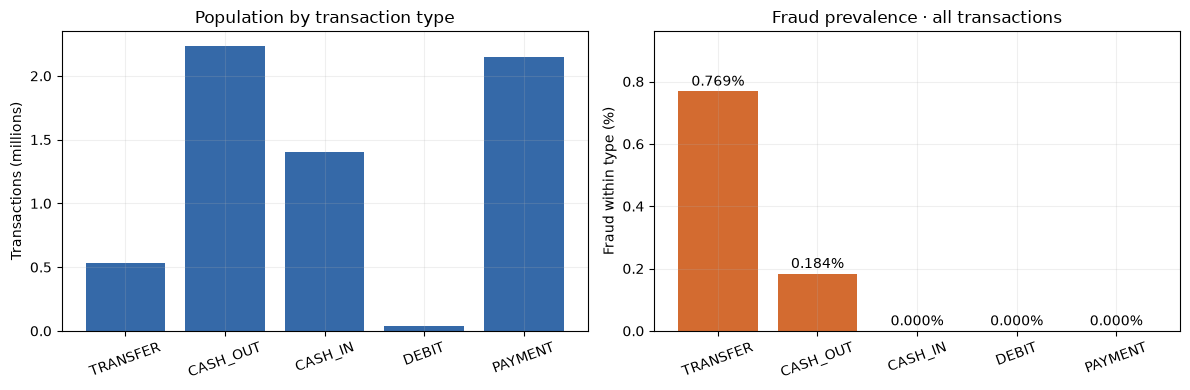

In [3]:
risk = df.loc[df.type.isin(RISK_TYPES)].copy()
by_type = df.groupby('type', observed=True).isFraud.agg(
    transactions='size', fraud_count='sum', fraud_prevalence='mean').sort_values('fraud_prevalence', ascending=False)
by_type['fraud_pct_within_type'] = by_type.fraud_prevalence * 100
population = pd.DataFrame([
    {'population': name, 'transactions': len(data), 'fraud_count': int(data.isFraud.sum()),
     'fraud_pct': 100 * data.isFraud.mean(),
     'legitimate_per_fraud': int(data.isFraud.eq(0).sum()) / int(data.isFraud.sum())}
    for name, data in [('All transactions', df), ('TRANSFER and CASH_OUT', risk)]
]).set_index('population')
display(population.round(4))
display(by_type.round(6))
save_table(population.reset_index(), 'eda_population')
save_table(by_type.reset_index(), 'eda_by_type')
all_type_time = df.groupby('step').isFraud.agg(transactions='size', fraud_count='sum')
save_table(all_type_time.reset_index(), 'eda_all_type_time')
del df

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_type.index.astype(str), by_type.transactions / 1_000_000, color='#3569a8')
axes[0].set(ylabel='Transactions (millions)', title='Population by transaction type')
axes[1].bar(by_type.index.astype(str), by_type.fraud_pct_within_type, color='#d36b30')
for x, value in enumerate(by_type.fraud_pct_within_type):
    axes[1].annotate(f'{value:.3f}%', (x, value), ha='center', xytext=(0, 4), textcoords='offset points')
axes[1].set(ylabel='Fraud within type (%)', title='Fraud prevalence · all transactions', ylim=(0, by_type.fraud_pct_within_type.max() * 1.25))
for ax in axes: ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
save_figure(fig, 'eda_population')
plt.show()

### Amounts and opening balances

Summaries below use only TRANSFER/CASH_OUT transactions. Counts and quartiles are reported separately for each label and type.
Histograms are normalised within each class and share bins, so the many legitimate transactions do not hide the fraud class.
The `log10(1 + value)` axis includes zero values and compresses the long tail; it does not change the underlying amounts.
Opening-balance patterns are descriptive evidence, not confirmation that the field is safe for live prediction.

amount                                                     \
                  count       mean         std   min        25%        50%   
fraud_status                                                                 
Fraud            8213.0  1467967.3  2404252.95  0.00  127091.33  441423.44   
Legitimate    2762196.0   314115.5   877144.15  0.01   82908.23  171034.46   

                                      oldbalanceOrg                          \
                     75%          max         count        mean         std   
fraud_status                                                                  
Fraud         1517771.48  10000000.00        8213.0  1649667.61  3547719.44   
Legitimate     305994.18  92445516.64     2762196.0    42879.69   135200.89   

                                                                  
              min        25%        50%         75%          max  
fraud_status                                                      
Fraud         0.0  125822.44  438983.45  1517771.48  59585040.37  
Legitimate    0.0       0.00     283.00    30790.00  43818855.30

amount                                            \
                           count        mean         std    min        25%   
type     fraud_status                                                        
CASH_OUT Fraud            4116.0  1455102.59  2393841.79   0.00  125464.45   
         Legitimate    2233384.0   173917.16   131222.24   0.01   72627.69   
TRANSFER Fraud            4097.0  1480891.67  2414890.38  63.80  128417.96   
         Legitimate     528812.0   906229.01  1874155.26   2.60  216570.76   

                                                          oldbalanceOrg  \
                             50%         75%          max         count   
type     fraud_status                                                     
CASH_OUT Fraud         435516.90  1500761.03  10000000.00        4116.0   
         Legitimate    146946.56   246181.18   2847566.62     2233384.0   
TRANSFER Fraud         445705.76  1534985.07  10000000.00        4097.0   
         Legitimate    486521.91   972733.64  92445516.64      528812.0   

                                                                          \
                             mean         std  min        25%        50%   
type     fraud_status                                                      
CASH_OUT Fraud         1453869.05  2394505.61  0.0  123231.00  433677.74   
         Legitimate      43429.23   133880.16  0.0       0.00     539.00   
TRANSFER Fraud         1846374.19  4404157.37  0.0  127564.33  444898.97   
         Legitimate      40558.76   140618.55  0.0       0.00       0.00   

                                                
                              75%          max  
type     fraud_status                           
CASH_OUT Fraud         1500761.03  10000000.00  
         Legitimate      31327.04  43818855.30  
TRANSFER Fraud         1534985.07  59585040.37  
         Legitimate      24854.00  25908675.06

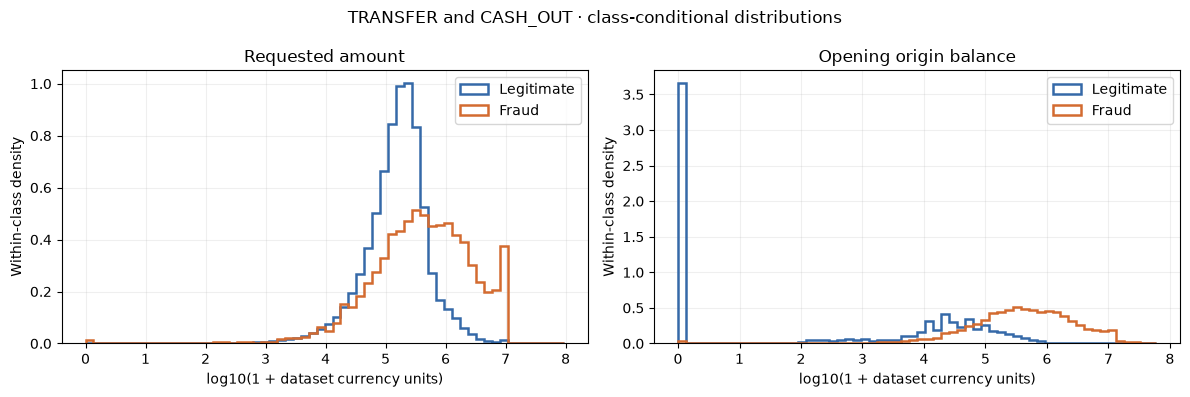

In [4]:
risk['fraud_status'] = risk.isFraud.map({0: 'Legitimate', 1: 'Fraud'})
pre_summary = risk.groupby('fraud_status')[['amount', 'oldbalanceOrg']].describe()
pre_by_type = risk.groupby(['type', 'fraud_status'], observed=True)[['amount', 'oldbalanceOrg']].describe()
display(pre_summary.round(2))
display(pre_by_type.round(2))
save_table(pre_summary, 'eda_amount_opening_summary', index=True)
save_table(pre_by_type, 'eda_amount_opening_by_type', index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feature, title in zip(axes, ['amount', 'oldbalanceOrg'], ['Requested amount', 'Opening origin balance']):
    values = np.log10(1 + risk[feature])
    bins = np.linspace(0, max(0.01, values.max()), 61)
    for label, colour in [(0, '#3569a8'), (1, '#d36b30')]:
        ax.hist(values.loc[risk.isFraud.eq(label)], bins=bins, density=True, histtype='step',
                linewidth=1.8, color=colour, label='Fraud' if label else 'Legitimate')
    ax.set(xlabel='log10(1 + dataset currency units)', ylabel='Within-class density', title=title)
    ax.legend()
fig.suptitle('TRANSFER and CASH_OUT · class-conditional distributions')
fig.tight_layout()
save_figure(fig, 'eda_initiation_distributions')
plt.show()

### Post-transaction accounting patterns — not primary model features

Retain the useful extended analysis of origin and destination balance residuals:
`opening origin − amount − closing origin` and `opening destination + amount − closing destination`.
These equations assume an outgoing debit and destination credit, and may not match cancellation or recording conventions.
A near-zero residual is defined as **absolute residual < 0.01 dataset currency units**, as in the original EDA.
It is not evidence of legitimacy, and a non-zero residual is not proof of fraud.

The conditional percentage P(near-zero residual | class) below uses all eligible transactions **within that class**.
Segment fraud prevalence instead measures P(fraud | residual combination and type). These are different questions.

abs_origin_balance_error                                         \
                                count        mean         std  min       25%   
fraud_status                                                                   
Fraud                          8213.0   10692.325  265146.131  0.0      0.00   
Legitimate                  2762196.0  286803.510  876375.192  0.0  52613.43   

                                                  abs_dest_balance_error  \
                     50%         75%          max                  count   
fraud_status                                                               
Fraud              0.000       0.000  10000000.00                 8213.0   
Legitimate    144200.825  280466.255  92445516.64              2762196.0   

                                                                     \
                    mean          std  min  25%      50%        75%   
fraud_status                                                          
Fraud         745138.586  1862744.923  0.0  0.0  9511.69  452294.74   
Legitimate     44302.661   583231.358  0.0  0.0     0.00       0.01   

                           
                      max  
fraud_status               
Fraud         10000000.00  
Legitimate    75885725.63

,zero_origin_error_pct_within_class,zero_dest_error_pct_within_class
fraud_status,,
Fraud,99.452,43.504
Legitimate,9.492,77.424


abs_origin_balance_error  abs_dest_balance_error  \
type     fraud_status                                                     
CASH_OUT Fraud                        1306.1252            1.396504e+04   
         Legitimate                 147994.1928            3.031327e+04   
TRANSFER Fraud                       20122.0542            1.479703e+06   
         Legitimate                 873050.6225            1.033854e+05   

                       zero_origin_error  zero_dest_error  
type     fraud_status                                      
CASH_OUT Fraud                    0.9942           0.8676  
         Legitimate               0.1084           0.7730  
TRANSFER Fraud                    0.9949           0.0005  
         Legitimate               0.0379           0.7793

transactions  fraud_count  \
type     zero_origin_error zero_dest_error                              
CASH_OUT False             False                  458275            7   
                           True                  1532995           17   
         True              False                   49151          538   
                           True                   197079         3554   
TRANSFER False             False                  112457           19   
                           True                   396325            2   
         True              False                    8354         4076   
                           True                    15773            0   

                                            fraud_prevalence  
type     zero_origin_error zero_dest_error                    
CASH_OUT False             False                     0.00002  
                           True                      0.00001  
         True              False                     0.01095  
                           True                      0.01803  
TRANSFER False             False                     0.00017  
                           True                      0.00001  
         True              False                     0.48791  
                           True                      0.00000

,transactions,fraud_count,fraud_prevalence
amount,,,
"(-0.001, 34162.534]",277041,759,0.00274
"(34162.534, 66797.146]",277041,523,0.00189
"(66797.146, 99390.778]",277041,415,0.00150
"(99390.778, 133738.014]",277041,427,0.00154
"(133738.014, 171260.93]",277041,379,0.00137
"(171260.93, 215050.366]",277040,346,0.00125
"(215050.366, 270842.392]",277041,403,0.00145
"(270842.392, 352961.522]",277041,474,0.00171
"(352961.522, 544867.566]",277041,763,0.00275


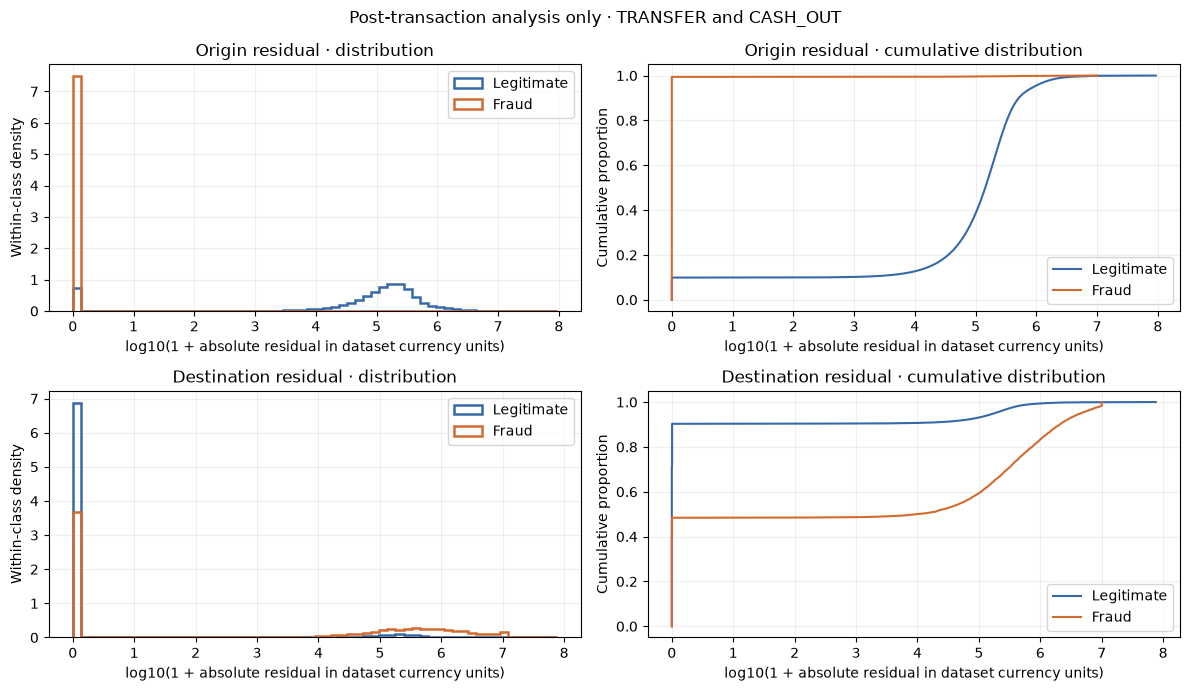

In [5]:
risk['abs_origin_balance_error'] = (risk.oldbalanceOrg - risk.amount - risk.newbalanceOrig).abs()
risk['abs_dest_balance_error'] = (risk.oldbalanceDest + risk.amount - risk.newbalanceDest).abs()
for side in ['origin', 'dest']:
    risk[f'zero_{side}_error'] = risk[f'abs_{side}_balance_error'].lt(0.01)
post_features = ['abs_origin_balance_error', 'abs_dest_balance_error', 'zero_origin_error', 'zero_dest_error']
post_summary = risk.groupby('fraud_status')[post_features].describe()
post_by_type = risk.groupby(['type', 'fraud_status'], observed=True)[post_features].mean()
near_zero = risk.groupby('fraud_status')[['zero_origin_error', 'zero_dest_error']].mean() * 100
segments = risk.groupby(['type', 'zero_origin_error', 'zero_dest_error'], observed=True).isFraud.agg(
    transactions='size', fraud_count='sum', fraud_prevalence='mean')
amount_bands = risk.groupby(pd.qcut(risk.amount, q=10, duplicates='drop'), observed=True).isFraud.agg(
    transactions='size', fraud_count='sum', fraud_prevalence='mean')
display(post_summary.round(3))
display(near_zero.rename(columns=lambda x: x + '_pct_within_class').round(3))
display(post_by_type.round(4))
display(segments.round(5))
display(amount_bands.round(5))
save_table(post_summary, 'eda_post_transaction_summary', index=True)
save_table(post_by_type, 'eda_post_transaction_by_type', index=True)
save_table(near_zero, 'eda_near_zero_by_class', index=True)
save_table(segments.reset_index(), 'eda_residual_segments')
save_table(amount_bands.reset_index(), 'eda_amount_bands')

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, (feature, title) in enumerate([('abs_origin_balance_error', 'Origin residual'),
                                       ('abs_dest_balance_error', 'Destination residual')]):
    bins = np.linspace(0, max(0.01, np.log10(1 + risk[feature].max())), 61)
    for label, colour in [(0, '#3569a8'), (1, '#d36b30')]:
        values = np.log10(1 + risk.loc[risk.isFraud.eq(label), feature].to_numpy())
        name = 'Fraud' if label else 'Legitimate'
        axes[row, 0].hist(values, bins=bins, density=True, histtype='step', linewidth=1.8, color=colour, label=name)
        probabilities = np.linspace(0, 1, 1001)
        axes[row, 1].plot(np.quantile(values, probabilities), probabilities, color=colour, label=name)
    axes[row, 0].set(title=title + ' · distribution', ylabel='Within-class density')
    axes[row, 1].set(title=title + ' · cumulative distribution', ylabel='Cumulative proportion')
    for ax in axes[row]:
        ax.set_xlabel('log10(1 + absolute residual in dataset currency units)')
        ax.legend()
fig.suptitle('Post-transaction analysis only · TRANSFER and CASH_OUT')
fig.tight_layout()
save_figure(fig, 'eda_post_transaction_residuals')
plt.show()

### Temporal coverage

Plot every recorded simulation step. Volume and class composition can change independently: a higher fraud percentage may
reflect more fraudulent transactions, fewer legitimate transactions, or both. A late period containing only fraud is a
coverage warning, not evidence that a real bank would suddenly receive only fraudulent payments. No split is changed here.

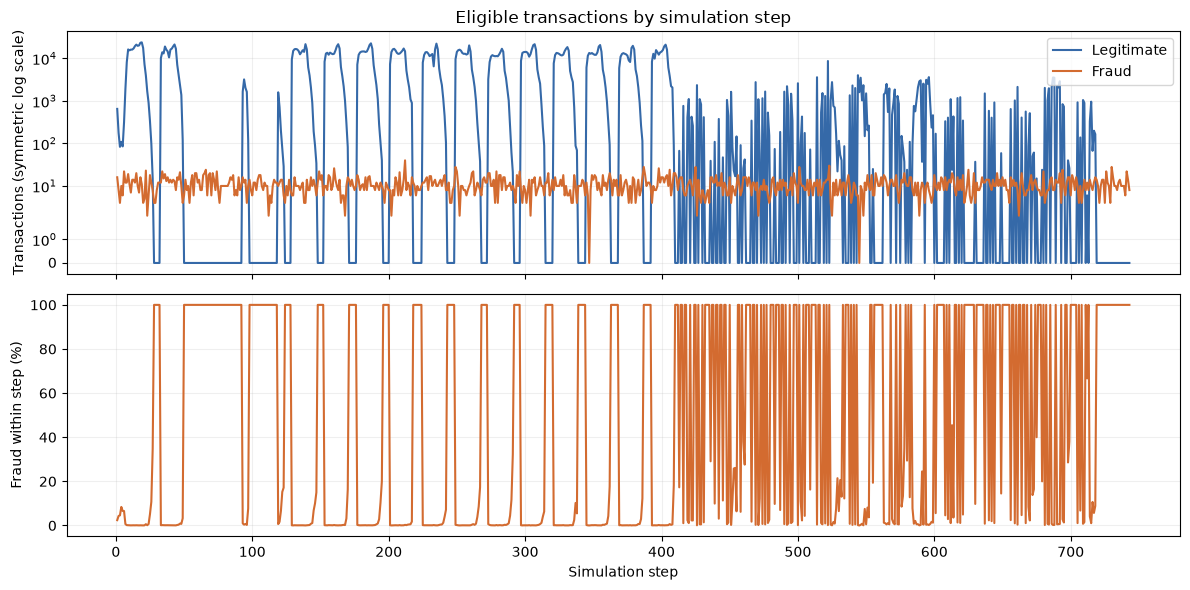

In [6]:
time_summary = risk.groupby('step').isFraud.agg(transactions='size', fraud_count='sum').reindex(
    range(int(risk.step.min()), int(risk.step.max()) + 1), fill_value=0)
time_summary['legitimate_count'] = time_summary.transactions - time_summary.fraud_count
time_summary['fraud_prevalence'] = time_summary.fraud_count / time_summary.transactions.replace(0, np.nan)
save_table(time_summary.rename_axis('step').reset_index(), 'eda_eligible_time')
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_summary.index, time_summary.legitimate_count, label='Legitimate', color='#3569a8')
axes[0].plot(time_summary.index, time_summary.fraud_count, label='Fraud', color='#d36b30')
axes[0].set(yscale='symlog', ylabel='Transactions (symmetric log scale)', title='Eligible transactions by simulation step')
axes[0].legend()
axes[1].plot(time_summary.index, 100 * time_summary.fraud_prevalence, color='#d36b30')
axes[1].set(xlabel='Simulation step', ylabel='Fraud within step (%)')
fig.tight_layout()
save_figure(fig, 'eda_time_coverage')
plt.show()

## Findings

The following narrative is generated from this run. Amount comparisons refer only to the eligible TRANSFER/CASH_OUT
population, avoiding the transaction-mix confounding in an all-type fraud/non-fraud comparison.

In [7]:
last_legitimate = int(risk.loc[risk.isFraud.eq(0), 'step'].max())
late = risk.loc[risk.step.gt(last_legitimate)]
summary = {
    'all_transactions': int(population.loc['All transactions', 'transactions']),
    'all_fraud': int(population.loc['All transactions', 'fraud_count']),
    'eligible_transactions': len(risk), 'eligible_fraud': int(risk.isFraud.sum()),
    'eligible_fraud_prevalence': float(risk.isFraud.mean()),
    'last_legitimate_step': last_legitimate, 'late_rows': len(late), 'late_fraud': int(late.isFraud.sum()),
    'missing_cells': int(missing.sum()), 'potential_duplicate_row_hashes': duplicate_hashes,
}
(ROOT / 'reports' / 'eda_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
legitimate_median = risk.loc[risk.isFraud.eq(0), 'amount'].median()
fraud_median = risk.loc[risk.isFraud.eq(1), 'amount'].median()
display(Markdown(
    f"- The file contains **{summary['all_transactions']:,} transactions** and **{summary['all_fraud']:,} fraud labels** "
    f"({population.loc['All transactions', 'fraud_pct']:.4f}% of all transactions).\n"
    f"- The eligible population contains **{len(risk):,} transactions**, with fraud prevalence "
    f"**{risk.isFraud.mean():.4%}**; it contains all fraud labels in this file.\n"
    f"- There are **{int(missing.sum()):,} missing cells** and **{duplicate_hashes:,} repeated full-row hashes**. "
    "This does not verify the semantic correctness of recorded balances.\n"
    f"- Within the eligible population, median amount is **{fraud_median:,.2f}** for fraud and "
    f"**{legitimate_median:,.2f}** for legitimate transactions, in dataset currency units.\n"
    f"- The last eligible legitimate transaction occurs at step **{last_legitimate}**. The following "
    f"**{len(late):,} recorded transactions** contain **{int(late.isFraud.sum()):,} fraud labels**. "
    "The file establishes the class-coverage change, not its cause.\n"
    "- Post-transaction residuals distinguish some recorded groups, but they are unsuitable inputs for an initiation-time decision."
))

- The file contains **6,362,620 transactions** and **8,213 fraud labels** (0.1291% of all transactions).
- The eligible population contains **2,770,409 transactions**, with fraud prevalence **0.2965%**; it contains all fraud labels in this file.
- There are **0 missing cells** and **0 repeated full-row hashes**. This does not verify the semantic correctness of recorded balances.
- Within the eligible population, median amount is **441,423.44** for fraud and **171,034.46** for legitimate transactions, in dataset currency units.
- The last eligible legitimate transaction occurs at step **718**. The following **296 recorded transactions** contain **296 fraud labels**. The file establishes the class-coverage change, not its cause.
- Post-transaction residuals distinguish some recorded groups, but they are unsuitable inputs for an initiation-time decision.

## Limitations

This is a single synthetic run with a changing time mix, not a representative sample of UK banking activity.
The publisher's cancellation warning prevents opening balances from being treated as verified operational inputs.
Closing-balance residuals are descriptive only. Zero values may reflect recording conventions; no meaning is imputed.
Linked TRANSFER/CASH_OUT legs may refer to the same stolen funds, so transaction values and counts are not incident losses.
There are no label-confirmation dates, customer outcomes or intervention costs. The full file has already been explored;
no part of it can now be advertised as a fully blind external test. All amounts remain in dataset currency units.